# Prepare Binary Dataset

This notebook prepares the merged ECG dataset for binary classification.

The goal is to create a target label that tells whether an ECG record is normal or abnormal.

## 1. Import libraries

`pandas` - load and prepare the dataset.  

`ast` - to safely read diagnostic codes stored as text.

`plt` - to visualize the graph.

In [45]:
import pandas as pd
import ast
import matplotlib.pyplot as plt

## 2. Load merged dataset

We load the merged dataset created in `03_merge_features_labels.ipynb`.  
It contains 12SL ECG features and PTB-XL diagnostic labels in one table.

In [46]:
merged_path = "../data/processed/merged_12sl_ptbxl.csv"

df = pd.read_csv(merged_path)

## 3. Preview merged dataset

This table shows the first rows of the merged dataset.

In [47]:
df.head()

,P_Area_I,P_PeakTime_I,Q_Area_I,Q_PeakTime_I,R_Area_I,R_PeakTime_I,S_Area_I,S_PeakTime_I,QRS_Balance_I,T_Area_I,...,T-_Amp_aVF,T_Morph_aVF,T_DurFull_aVF,P_Dur_Global,P_Found_Global,HR__Global,P_Term_V1,scp_codes,scp_codes_ext,scp_codes_ext_snomed
0,0.264,64.0,0.000,0.0,0.737,30.0,0.000,0.0,629.0,0.819,...,0.000,1,208.0,112.0,1,64.0,0.000,"[('NORM', 100.0), ('LVOLT', 100.0), ('SR', 100...","[('NORM', 100.0), ('LVOLT', 100.0), ('SR', 100...","[(320536, 100.0), (441840, 100.0), (4008453, 1..."
1,-0.047,6.0,0.015,8.0,0.794,36.0,1.246,76.0,205.0,2.206,...,-0.078,-1,127.0,66.0,1,75.0,0.000,"[('CRBBB', 100.0), ('SARRH', 100.0)]","[('CRBBB', 100.0), ('SARRH', 100.0)]","[(134057, 100.0), (313791, 100.0), (314059, 10..."
2,0.000,0.0,0.000,0.0,0.792,38.0,1.389,74.0,141.0,1.155,...,-0.078,-1,66.0,NaN,0,169.0,0.000,"[('CRBBB', 100.0), ('AFIB', 100.0)]","[('CRBBB', 100.0), ('AFIB', 100.0)]","[(134057, 100.0), (313217, 100.0), (313791, 10..."
3,0.196,74.0,0.000,0.0,0.947,56.0,0.000,0.0,439.0,-0.339,...,0.000,-1,0.0,114.0,1,79.0,0.000,"[('ASMI', 100.0), ('ISCAL', 100.0), ('LAFB', 1...","[('ASMI', 100.0), ('ISCAL', 100.0), ('LAFB', 1...","[(134057, 100.0), (313791, 100.0), (316998, 10..."
4,0.287,102.0,0.000,0.0,1.021,36.0,0.000,0.0,937.0,0.756,...,-0.034,-2,170.0,136.0,1,92.0,6.612,"[('NDT', 100.0), ('SR', 100.0)]","[('NDT', 100.0), ('SR', 100.0)]","[(320536, 100.0), (441840, 100.0), (4008453, 1..."


## 4. Create binary target

We create a binary target for the classification task.

The rule is:

- `target = 0` - normal ECG, when `NORM` certainty is greater than or equal to 80
- `target = 1` - abnormal ECG, when `NORM` is missing or its certainty is below 80

In [48]:
def get_norm_certainty(codes_text):
    try:
        codes = ast.literal_eval(codes_text)
        # ast.literal_eval turns {'NORM': 100.0, 'SR': 100.0} text into python object (dictionary)
    except:
        return 0

    if isinstance(codes, dict): # if data is dict (dictionary) then:
        return codes.get("NORM", 0)

    if isinstance(codes, list): # when we have pair in `codes` [("NORM", 100.0), ("SR", 100.0)]:
        for item in codes:
            if len(item) >= 2 and item[0] == "NORM":
                return item[1]

    return 0


df = df.copy()

df["norm_certainty"] = df["scp_codes"].apply(get_norm_certainty)

df["target"] = df["norm_certainty"].apply(lambda value: 0 if value >= 80 else 1)

df[["ecg_id", "scp_codes", "norm_certainty", "target"]].head()

,ecg_id,scp_codes,norm_certainty,target
0,1,"[('NORM', 100.0), ('LVOLT', 100.0), ('SR', 100...",100.0,0
1,21803,"[('CRBBB', 100.0), ('SARRH', 100.0)]",0.0,1
2,21804,"[('CRBBB', 100.0), ('AFIB', 100.0)]",0.0,1
3,21805,"[('ASMI', 100.0), ('ISCAL', 100.0), ('LAFB', 1...",0.0,1
4,21806,"[('NDT', 100.0), ('SR', 100.0)]",0.0,1


## 5. Check NORM certainty distribution

We check how often each `NORM` certainty value appears in the dataset.

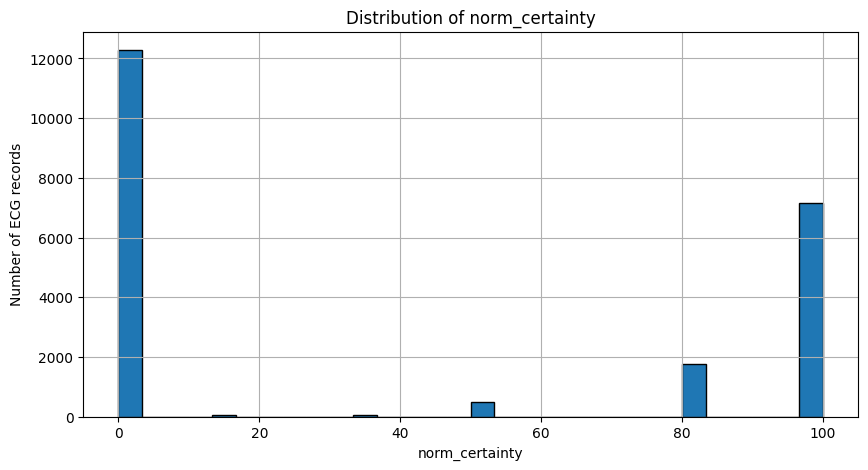

In [49]:
plt.figure(figsize=(10, 5))
plt.hist(df["norm_certainty"], bins=30, edgecolor="black")
plt.title("Distribution of norm_certainty")
plt.xlabel("norm_certainty")
plt.ylabel("Number of ECG records")
plt.grid(True)
plt.show()

In [50]:
df["norm_certainty"].value_counts(normalize=True).sort_index() * 100

norm_certainty
0.0      56.355796
15.0      0.174320
34.0      0.004587
35.0      0.169733
50.0      2.316620
80.0      8.078352
100.0    32.900592
Name: proportion, dtype: float64

A threshold of 80 was selected because it keeps records with strong `NORM` certainty as normal ECG, while lower-certainty records are treated as abnormal or uncertain.


## 6. Check target distribution

We check how many ECG records are labeled as normal and abnormal.

In [51]:
df["target"].value_counts()

target
1    12866
0     8933
Name: count, dtype: int64

`target = 0` means normal ECG.  
`target = 1` means abnormal or uncertain ECG.

In [52]:
(df["target"].value_counts(normalize=True) * 100).round(2)

target
1    59.02
0    40.98
Name: proportion, dtype: float64

This shows the percentage of normal and abnormal ECG records in the dataset.

The dataset is slightly imbalanced, because abnormal or uncertain ECG records are more common than normal ECG records.  

However, both classes are well represented, so the dataset is suitable for the first binary classification model.

## 7. Select feature columns

We select only numerical ECG feature columns.

Diagnostic label columns are removed because they should not be used as input features for the model.

In [53]:
columns_to_remove = [
    "ecg_id",
    "scp_codes",
    "scp_codes_ext",
    "scp_codes_ext_snomed",
    "norm_certainty",
    "target"
]

X = df.drop(columns=columns_to_remove, errors="ignore")
X = X.select_dtypes(include="number")

y = df["target"]

X.head()

,P_Area_I,P_PeakTime_I,Q_Area_I,Q_PeakTime_I,R_Area_I,R_PeakTime_I,S_Area_I,S_PeakTime_I,QRS_Balance_I,T_Area_I,...,T+_Dur_aVF,T-_Dur_aVF,T+_Amp_aVF,T-_Amp_aVF,T_Morph_aVF,T_DurFull_aVF,P_Dur_Global,P_Found_Global,HR__Global,P_Term_V1
0,0.264,64.0,0.000,0.0,0.737,30.0,0.000,0.0,629.0,0.819,...,208.0,0.0,0.151,0.000,1,208.0,112.0,1,64.0,0.000
1,-0.047,6.0,0.015,8.0,0.794,36.0,1.246,76.0,205.0,2.206,...,0.0,127.0,0.000,-0.078,-1,127.0,66.0,1,75.0,0.000
2,0.000,0.0,0.000,0.0,0.792,38.0,1.389,74.0,141.0,1.155,...,0.0,66.0,0.000,-0.078,-1,66.0,NaN,0,169.0,0.000
3,0.196,74.0,0.000,0.0,0.947,56.0,0.000,0.0,439.0,-0.339,...,0.0,0.0,0.000,0.000,-1,0.0,114.0,1,79.0,0.000
4,0.287,102.0,0.000,0.0,1.021,36.0,0.000,0.0,937.0,0.756,...,104.0,66.0,39.000,-0.034,-2,170.0,136.0,1,92.0,6.612


## 8. Check feature dataset shape

In [54]:
X.shape

(21799, 782)

This shows the number of records and numerical ECG features before removing missing values.

## 9. Check missing values in features

In [55]:
X.isna().sum().sort_values(ascending=False).head(30)

P_On_Global             2032
P_Off_Global            2032
P_Dur_Global            2032
PR_Int_Global           2013
P_AxisFront_Global      1994
HR_Atrial_Global        1582
T_AxisFront_Global         4
R_AxisFrontal_Global       1
S_PeakTime_I               0
QRS_Balance_I              0
T_Area_I                   0
T_PeakTime_I               0
QRS_Area_I                 0
P_Area_II                  0
P_PeakTime_II              0
T+_Amp_aVR                 0
R_PeakTime_V1              0
P_Area_I                   0
Q_PeakTime_II              0
R_Area_II                  0
R_PeakTime_II              0
S_Area_II                  0
S_PeakTime_II              0
QRS_Balance_II             0
T_Area_II                  0
T_PeakTime_II              0
QRS_Area_II                0
P_Area_V1                  0
P_PeakTime_V1              0
Q_Area_V1                  0
dtype: int64

This output shows which feature columns may need cleaning before model training.

## 10. Remove columns with many missing values

We remove feature columns with more than 5% missing values.

In [56]:
missing_ratio = X.isna().mean()

columns_to_keep = missing_ratio[missing_ratio <= 0.05].index

X_clean = X[columns_to_keep]

X.shape, X_clean.shape

((21799, 782), (21799, 776))

The number of feature columns decreased from **782** to **776**.  
This means that only **6 columns** had more than 5% missing values and were removed.

## 11. Fill remaining missing values

In [57]:
X_clean = X_clean.fillna(X_clean.median())

X_clean.isna().sum().sum()

np.int64(0)

Remaining missing values were filled with the median value of each feature column. 

After filling missing values with column medians, the total number of missing values in `X_clean` is **0**.

## 12. Create final prepared dataset

We combine the cleaned ECG features with `ecg_id` and the binary target label.

In [58]:
df_prepared = X_clean.copy()

df_prepared.insert(0, "ecg_id", df["ecg_id"])
df_prepared["target"] = y

df_prepared.head()

,ecg_id,P_Area_I,P_PeakTime_I,Q_Area_I,Q_PeakTime_I,R_Area_I,R_PeakTime_I,S_Area_I,S_PeakTime_I,QRS_Balance_I,...,T+_Dur_aVF,T-_Dur_aVF,T+_Amp_aVF,T-_Amp_aVF,T_Morph_aVF,T_DurFull_aVF,P_Found_Global,HR__Global,P_Term_V1,target
0,1,0.264,64.0,0.000,0.0,0.737,30.0,0.000,0.0,629.0,...,208.0,0.0,0.151,0.000,1,208.0,1,64.0,0.000,0
1,21803,-0.047,6.0,0.015,8.0,0.794,36.0,1.246,76.0,205.0,...,0.0,127.0,0.000,-0.078,-1,127.0,1,75.0,0.000,1
2,21804,0.000,0.0,0.000,0.0,0.792,38.0,1.389,74.0,141.0,...,0.0,66.0,0.000,-0.078,-1,66.0,0,169.0,0.000,1
3,21805,0.196,74.0,0.000,0.0,0.947,56.0,0.000,0.0,439.0,...,0.0,0.0,0.000,0.000,-1,0.0,1,79.0,0.000,1
4,21806,0.287,102.0,0.000,0.0,1.021,36.0,0.000,0.0,937.0,...,104.0,66.0,39.000,-0.034,-2,170.0,1,92.0,6.612,1


## 13. Check final dataset shape

In [59]:
df_prepared.shape

(21799, 778)

## 14. Check final target distribution

We check if the target column was saved correctly in the final dataset.

In [60]:
df_prepared["target"].value_counts()

target
1    12866
0     8933
Name: count, dtype: int64

In [61]:
(df_prepared["target"].value_counts(normalize=True) * 100).round(2)

target
1    59.02
0    40.98
Name: proportion, dtype: float64

The target distribution stayed the same after cleaning.

This means that no ECG records were removed, only feature columns were cleaned.

## 15. Save prepared dataset

We save the prepared binary dataset to the `data/processed/` folder.

In [62]:
output_path = "../data/processed/12sl_norm_binary_clean.csv"

df_prepared.to_csv(output_path, index=False)

output_path

'../data/processed/12sl_norm_binary_clean.csv'

The prepared dataset was saved and can be used in the next notebook for training the first model.